In [537]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [538]:
usdt_data = pd.read_csv("USDT-USD.csv")

In [539]:
usdt_data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-09,1.01087,1.01327,0.996515,1.00818,1.00818,3.581880e+08
1,2017-11-10,1.00650,1.02423,0.995486,1.00601,1.00601,7.564460e+08
2,2017-11-11,1.00598,1.02621,0.995799,1.00899,1.00899,7.462280e+08
3,2017-11-12,1.00602,1.10591,0.967601,1.01247,1.01247,1.466060e+09
4,2017-11-13,1.00448,1.02929,0.975103,1.00935,1.00935,7.678840e+08


In [540]:
usdt_data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str')

In [541]:
usdt_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1822 entries, 0 to 1821
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1822 non-null   str    
 1   Open       1821 non-null   float64
 2   High       1821 non-null   float64
 3   Low        1821 non-null   float64
 4   Close      1821 non-null   float64
 5   Adj Close  1821 non-null   float64
 6   Volume     1821 non-null   float64
dtypes: float64(6), str(1)
memory usage: 99.8 KB


In [542]:
usdt_close_data = usdt_data.drop(['Open', 'High', 'Low', 'Adj Close', 'Volume'], axis= 1)

In [543]:
usdt_close_data.head()

,Date,Close
0,2017-11-09,1.00818
1,2017-11-10,1.00601
2,2017-11-11,1.00899
3,2017-11-12,1.01247
4,2017-11-13,1.00935


In [544]:
type(usdt_close_data)

pandas.DataFrame

In [545]:
usdt_close_data.duplicated().sum()

np.int64(0)

In [546]:
usdt_close_data.isnull().sum()

Date     0
Close    1
dtype: int64

In [547]:
usdt_close_data = usdt_close_data.dropna(subset=['Close'])

In [548]:
usdt_close_data.isnull().sum()

Date     0
Close    0
dtype: int64

In [549]:
# plt.figure(figsize=(14, 6))
# plt.plot(usdt_close_data["Date"], usdt_close_data["Close"])
# plt.title("Amazon Stock Price")
# plt.xlabel("Date")
# plt.ylabel("Price")
# plt.grid()
# plt.show()

In [550]:
time_window = 30
output_days = 1
X = []
y = []
for index in range(0, len(usdt_close_data) - time_window - output_days + 1):
    x_start_index = index
    x_end_index = index + time_window

    X.append(usdt_close_data['Close'].iloc[x_start_index : x_end_index].tolist())
    y.append(usdt_close_data['Close'].iloc[x_end_index])

In [551]:
print(len(usdt_close_data))
print(len(X))
print(1822-30)
print(len(y))

1821
1791
1792
1791


### Train/Test

In [552]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

In [553]:
print(X_train)

[[1.000372, 1.000292, 1.000348, 1.000435, 1.000275, 1.000127, 1.000239, 1.000296, 1.000314, 1.000218, 1.000343, 1.000202, 1.000157, 1.000234, 1.000228, 1.000344, 1.000145, 1.000073, 1.000153, 1.000191, 1.00002, 1.000155, 1.000113, 0.999955, 1.000045, 1.000038, 0.999988, 0.999982, 0.999921, 0.999854], [1.000177, 1.000209, 1.000253, 1.000406, 1.000336, 1.000376, 1.000271, 1.000174, 1.000115, 1.000073, 0.999999, 1.00006, 0.999974, 0.999994, 0.999984, 0.999992, 1.000039, 1.00008, 1.000043, 1.000019, 1.000028, 1.000032, 1.000081, 1.000016, 1.00001, 1.000089, 1.000074, 1.000061, 1.000038, 1.000049], [1.01226, 1.00728, 1.0049, 1.01344, 1.00253, 0.998634, 1.00899, 1.00157, 1.00932, 1.00599, 1.00128, 1.00171, 1.00608, 1.00202, 1.01612, 1.00662, 1.03415, 1.01453, 1.02311, 1.00454, 1.00111, 0.999861, 1.00504, 1.00505, 0.997484, 0.999595, 1.00414, 0.993325, 0.98879, 0.995319], [0.998088, 1.00103, 1.00004, 0.999843, 0.997496, 0.996505, 0.998791, 0.997951, 0.997118, 0.997887, 0.998919, 0.99891, 0.99

#### Pre_processing

In [554]:
from sklearn.preprocessing import MinMaxScaler

feature_data = MinMaxScaler()
X_train_norm = feature_data.fit_transform(X_train)
X_test_norm = feature_data.transform(X_test)

target_data = MinMaxScaler()
y_train_norm = target_data.fit_transform(np.reshape(y_train,(-1,1)))
y_test_norm = target_data.transform(np.reshape(y_test, (-1, 1)))

In [555]:
print(f"X_train Shape: {X_train_norm.shape} - X_test Shape: {X_test_norm.shape}")
print(f"y_train Shape: {y_train_norm.shape} - y_test Shape: {y_test_norm.shape}")

X_train Shape: (1611, 30) - X_test Shape: (180, 30)
y_train Shape: (1611, 1) - y_test Shape: (180, 1)


## LinearRegression

In [556]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_norm, y_train_norm)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [557]:
lr_prediction = lr.predict(X_test_norm)

In [558]:
print("Train SVR:", lr.score(X_train_norm, y_train_norm))
print("Test SVR:", lr.score(X_test_norm, y_test_norm))

Train SVR: 0.5452431378441902
Test SVR: 0.5930193416024426


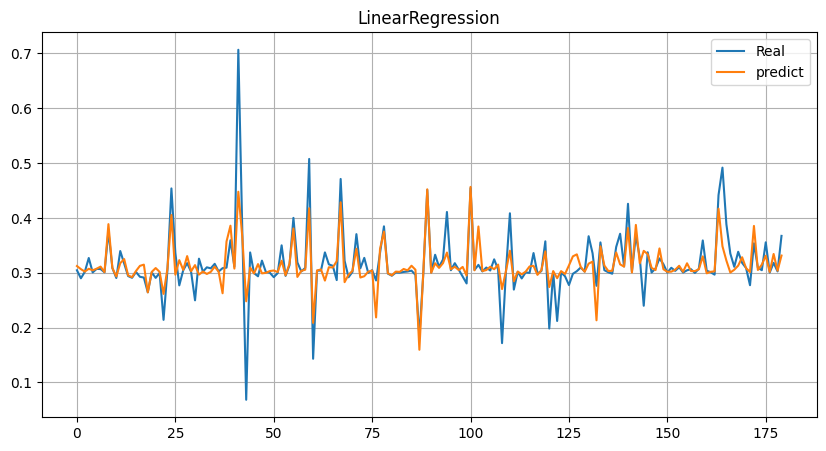

In [559]:
plt.figure(figsize=(10, 5))
plt.plot(y_test_norm, label= "Real")
plt.plot(lr_prediction, label= "predict")
plt.title("LinearRegression")
plt.legend()
plt.grid()
plt.show()

## Random Forest

In [560]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=5)
rf.fit(X_train_norm, y_train_norm)

e:\Python Git\ML\breast_cancer_classification\.venv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [561]:
rf_prediction = rf.predict(X_test_norm)

In [562]:
print("Train rf:", rf.score(X_train_norm, y_train_norm))
print("Test rf:", rf.score(X_test_norm, y_test_norm))

Train rf: 0.7515933589348149
Test rf: 0.6157291785204264


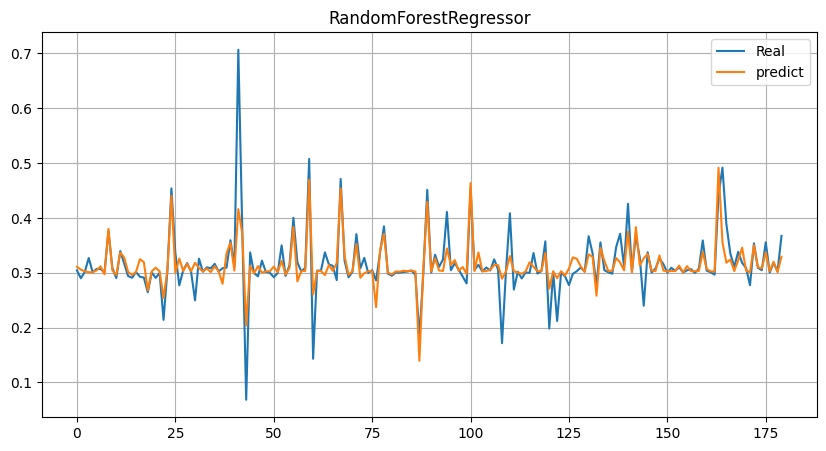

In [563]:
plt.figure(figsize=(10, 5))
plt.plot(y_test_norm, label= "Real")
plt.plot(rf_prediction, label= "predict")
plt.title("RandomForestRegressor")
plt.legend()
plt.grid()
plt.show()

In [564]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
gb.fit(X_train_norm, y_train_norm)

e:\Python Git\ML\breast_cancer_classification\.venv\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [565]:
gb_prediction = gb.predict(X_test_norm)

In [566]:
print("Train rf:", gb.score(X_train_norm, y_train_norm))
print("Test rf:", gb.score(X_test_norm, y_test_norm))

Train rf: 0.969060255510268
Test rf: 0.5186598912096658


## TEST

In [567]:
### example
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[1, 2, 3]
[2, 3, 4]
[3, 4, 5]
[4, 5, 6]
[5, 6, 7]
[6, 7, 8]
[7, 8, 9]
[8, 9, 10]
8

8

In [568]:
example = [i for i in range(20)]
time_w = 4
future = 2
input = []
output = []
for i in range(0,len(example)-time_w - future):
    input.append(example[i:i+time_w])
    output.append(example[i+time_w+future])

In [569]:
for i in range(len(input)):
    print(f"{input[i]} => {output[i]}")

[0, 1, 2, 3] => 6
[1, 2, 3, 4] => 7
[2, 3, 4, 5] => 8
[3, 4, 5, 6] => 9
[4, 5, 6, 7] => 10
[5, 6, 7, 8] => 11
[6, 7, 8, 9] => 12
[7, 8, 9, 10] => 13
[8, 9, 10, 11] => 14
[9, 10, 11, 12] => 15
[10, 11, 12, 13] => 16
[11, 12, 13, 14] => 17
[12, 13, 14, 15] => 18
[13, 14, 15, 16] => 19
